In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from section import Section

In [2]:
df = pd.read_csv("../dataset/section_bis.txt",
                 delimiter="\t",
                 decimal=".")

In [3]:
section = Section()
section.from_df(df, x_field="X", z_field="Z")

True

In [4]:
section.xz

[(0.0, 548.6),
 (1.07, 548.6),
 (2.13, 548.62),
 (3.2, 548.21),
 (4.27, 547.25),
 (5.33, 546.43),
 (6.4, 545.76),
 (7.47, 545.5),
 (8.53, 545.22),
 (9.6, 544.98),
 (10.67, 544.77),
 (11.73, 544.86),
 (12.8, 545.16),
 (13.87, 545.76),
 (14.93, 546.17),
 (16.0, 546.77),
 (17.07, 547.23),
 (18.13, 547.71),
 (19.2, 548.29),
 (20.27, 548.92),
 (21.33, 549.55),
 (22.4, 550.38),
 (23.47, 550.84),
 (24.54, 550.42),
 (25.6, 550.38),
 (26.67, 550.36)]

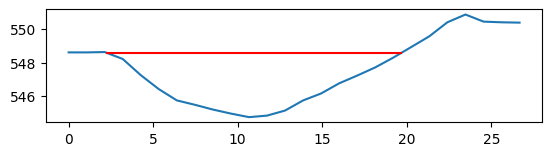

In [5]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.plot(section.x, section.z)
for line in section.water_lines(altitude=548.57):
    ax.plot([x for x, z in line], [z for x, z in line], color="Red")
plt.show()

In [6]:
min(section.z)

544.77

In [7]:
section.ferguson(548., 0.05, 0.05)

328.84691528263517

In [8]:
altitudes = np.arange(min(section.z), max(section.z), 0.1)
if max(section.z) not in altitudes:
    altitudes = np.append(altitudes, max(section.z))

In [9]:
altitudes

array([544.77, 544.87, 544.97, 545.07, 545.17, 545.27, 545.37, 545.47,
       545.57, 545.67, 545.77, 545.87, 545.97, 546.07, 546.17, 546.27,
       546.37, 546.47, 546.57, 546.67, 546.77, 546.87, 546.97, 547.07,
       547.17, 547.27, 547.37, 547.47, 547.57, 547.67, 547.77, 547.87,
       547.97, 548.07, 548.17, 548.27, 548.37, 548.47, 548.57, 548.67,
       548.77, 548.87, 548.97, 549.07, 549.17, 549.27, 549.37, 549.47,
       549.57, 549.67, 549.77, 549.87, 549.97, 550.07, 550.17, 550.27,
       550.37, 550.47, 550.57, 550.67, 550.77, 550.84])

In [21]:
results = {
    "heights" : [0],
    "discharges" : [0]
}

dh = 0.1
heights = np.arange(dh, max(section.z)-min(section.z), dh)
if max(section.z)-min(section.z) not in heights:
    heights = np.append(heights, max(section.z)-min(section.z))

for height in heights:
    discharge = section.ferguson(min(section.z) + height, 0.05, 0.05)
    if discharge:
        results["heights"].append(float(height))
        results["discharges"].append(discharge)
    

In [22]:
results

{'heights': [0,
  0.1,
  0.2,
  0.30000000000000004,
  0.4,
  0.5,
  0.6,
  0.7000000000000001,
  0.8,
  0.9,
  1.0,
  1.1,
  1.2000000000000002,
  1.3000000000000003,
  1.4000000000000001,
  1.5000000000000002,
  1.6,
  1.7000000000000002,
  1.8000000000000003,
  1.9000000000000001,
  2.0,
  2.1,
  2.2,
  2.3000000000000003,
  2.4000000000000004,
  2.5000000000000004,
  2.6,
  2.7,
  2.8000000000000003,
  2.9000000000000004,
  3.0000000000000004,
  3.1,
  3.2,
  3.3000000000000003,
  3.4000000000000004,
  3.5000000000000004,
  3.6,
  3.7,
  3.8000000000000003],
 'discharges': [0,
  0.032211087681293986,
  0.3095172267380639,
  0.9758892466401115,
  2.112355015906309,
  3.8528500198602855,
  6.151166909678645,
  9.012879813475678,
  12.440049478891845,
  16.4875357338599,
  21.236126056645674,
  26.954085062995578,
  33.3477330352394,
  40.43155504070316,
  48.22126664153828,
  56.979572293207355,
  66.44369447796271,
  76.66858263814478,
  87.67643778216181,
  99.39992556638882,
  111

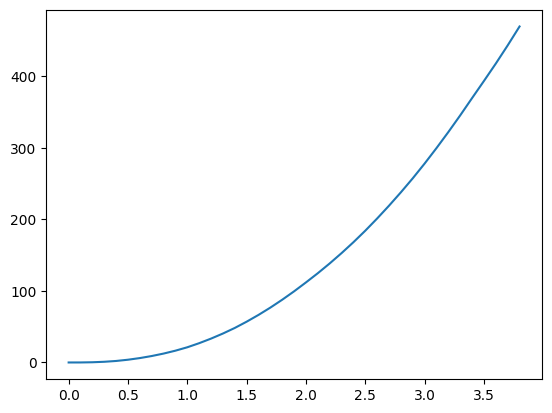

In [23]:
fig, ax = plt.subplots()
ax.plot(results["heights"], results["discharges"])
plt.show()